<a href="https://colab.research.google.com/github/tamaraeliana908-art/LABORATORIO-11/blob/main/Copia_de_Laboratorio_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HERRAMIENTAS A UTILIZAR:


**PERPLEXITY:**

https://www.perplexity.ai/

**GITHUB:**
https://github.com/




Prompt 1: Crea un codigo python donde cargarás el dataset Diabetes de scikit-learn, que contiene
variables relacionadas con la salud y una variable de salida (target) que mide el nivel de
progreso de la enfermedad. Los datos serán organizados en un DataFrame para
facilitar el manejo.
2. Tareas:
Importar las librerías necesarias.
Cargar los datos utilizando load_diabetes y convertirlos a un DataFrame con
pandas.
Mostrar las primeras filas del DataFrame para explorar los datos

In [1]:
# Importar librerías necesarias
import pandas as pd
from sklearn.datasets import load_diabetes

# Cargar el dataset Diabetes
diabetes = load_diabetes()

# Convertir a DataFrame
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Agregar la variable objetivo
df_diabetes["target"] = diabetes.target

# Mostrar las primeras filas
print(df_diabetes.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Prompt 2: Crea un codigo python pero En esta sección, aplicarás un modelo de regresión lineal para predecir los
valores del target (progresión de la enfermedad) en función del índice de masa
corporal (BMI), una de las variables predictoras.
2. Tareas:
Laboratorio 12
Dividir los datos en conjuntos de entrenamiento y prueba usando
train_test_split.
Entrenar un modelo de regresión lineal con la variable BMI como predictora.
Evaluar el modelo utilizando el error cuadrático medio (MSE) como métrica.

In [2]:
# Importar librerías necesarias
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Cargar el dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Seleccionar variable predictora y variable objetivo
X = df[["bmi"]]
y = df["target"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar con MSE
mse = mean_squared_error(y_test, y_pred)

print("Coeficiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("MSE:", mse)

Coeficiente: 998.5776891375598
Intercepto: 152.00335421448167
MSE: 4061.8259284949268


Prompt 3: Crea un codigo python donde Aplicarás un modelo de regresión logística para clasificar si el valor del
target es mayor que 140. Esto convierte el problema en un problema de clasificación
binaria.
2. Tareas:
Convertir la variable dependiente (target) en binaria.
Dividir los datos en conjuntos de entrenamiento y prueba.
Entrenar un modelo de regresión logística y evaluar su precisión.

In [3]:
# Importar librerías necesarias
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Cargar el dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Convertir el target en binario:
# 1 si target > 140, 0 en caso contrario
df["target_binario"] = (df["target"] > 140).astype(int)

# Definir variables predictoras y variable objetivo binaria
X = df.drop(columns=["target", "target_binario"])
y = df["target_binario"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Crear y entrenar el modelo de regresión logística
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar precisión
accuracy = accuracy_score(y_test, y_pred)

print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.7752808988764045


Prompt 4: crea un codigo python donde Entrenarás un árbol de decisión para clasificar si el valor del target es
mayor que 140, y evaluarás su precisión sobre el conjunto de prueba.
2. Tareas:
Entrenar un modelo de árbol de decisión.
Realizar predicciones sobre el conjunto de prueba.
Evaluar el modelo utilizando la precisión.

In [4]:
# Importar librerías necesarias
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cargar el dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Convertir el target en variable binaria:
# 1 si target > 140, 0 si no
df["target_binario"] = (df["target"] > 140).astype(int)

# Definir variables predictoras y variable objetivo
X = df.drop(columns=["target", "target_binario"])
y = df["target_binario"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar el árbol de decisión
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)

print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.651685393258427


Prompt 5: Crea un codigo python donde Implementarás un Random Forest con múltiples árboles de decisión para
mejorar la robustez y precisión del modelo.
2. Tareas:
Entrenar un modelo de Random Forest con 100 árboles.
Realizar predicciones y evaluar la precisión del modelo.

In [5]:
# Importar librerías necesarias
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Cargar el dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Convertir el target en variable binaria:
# 1 si target > 140, 0 en caso contrario
df["target_binario"] = (df["target"] > 140).astype(int)

# Definir variables predictoras y variable objetivo
X = df.drop(columns=["target", "target_binario"])
y = df["target_binario"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar el modelo Random Forest con 100 árboles
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Realizar predicciones
y_pred = modelo.predict(X_test)

# Evaluar precisión
accuracy = accuracy_score(y_test, y_pred)

print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.7640449438202247


Prompt 6:  Crea un codigo python donde Usarás el modelo ARIMA (AutoRegressive Integrated Moving Average)
para analizar una serie temporal y realizar predicciones. ARIMA es comúnmente usado
para modelar y predecir datos de series temporales.
2. Tareas:
Crear una serie temporal simulada.
Ajustar un modelo ARIMA y realizar predicciones de los valores futuros.

Pronóstico:
2020-04-10    79.230885
2020-04-11    79.231003
2020-04-12    79.231078
2020-04-13    79.231125
2020-04-14    79.231155
2020-04-15    79.231173
2020-04-16    79.231185
2020-04-17    79.231193
2020-04-18    79.231197
2020-04-19    79.231200
Freq: D, Name: predicted_mean, dtype: float64


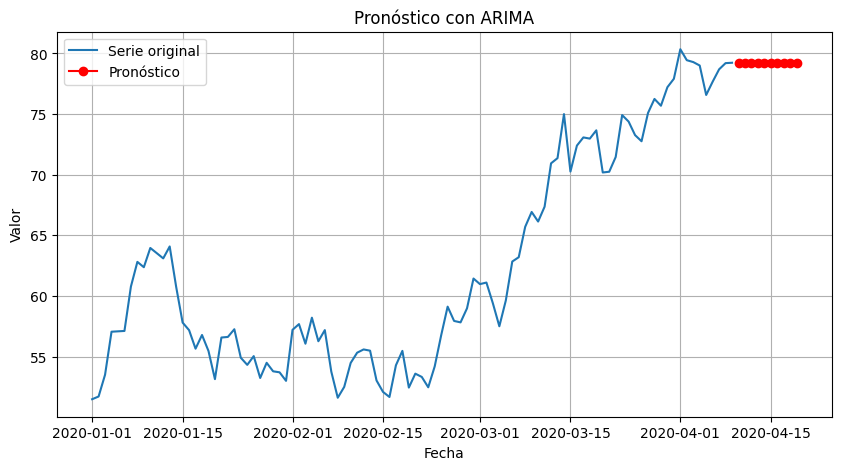

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Crear una serie temporal simulada
np.random.seed(42)
n = 100
fechas = pd.date_range(start="2020-01-01", periods=n, freq="D")

# Serie con tendencia + ruido
serie = pd.Series(50 + np.cumsum(np.random.normal(loc=0.5, scale=2, size=n)), index=fechas)

# 2. Ajustar el modelo ARIMA
# Parámetros típicos: p=1, d=1, q=1
modelo = ARIMA(serie, order=(1, 1, 1))
resultado = modelo.fit()

# 3. Realizar predicciones futuras
n_pasos = 10
pronostico = resultado.forecast(steps=n_pasos)

# Crear fechas futuras para las predicciones
fechas_futuras = pd.date_range(start=serie.index[-1] + pd.Timedelta(days=1), periods=n_pasos, freq="D")

# 4. Mostrar resultados
print("Pronóstico:")
print(pronostico)

# 5. Graficar serie original y predicciones
plt.figure(figsize=(10, 5))
plt.plot(serie, label="Serie original")
plt.plot(fechas_futuras, pronostico, label="Pronóstico", marker="o", color="red")
plt.title("Pronóstico con ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

Prompt 7:  Crea un codigo python donde descompondrás una serie temporal en sus componentes
principales: tendencia, estacionalidad y residuos.
2. Tareas:
 Descomponer la serie temporal simulada utilizando la función
seasonal_decompose.
Visualizar los componentes de la serie descompuesta.

/tmp/ipykernel_1859/4161118148.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start="2020-01-01", periods=n, freq="M")


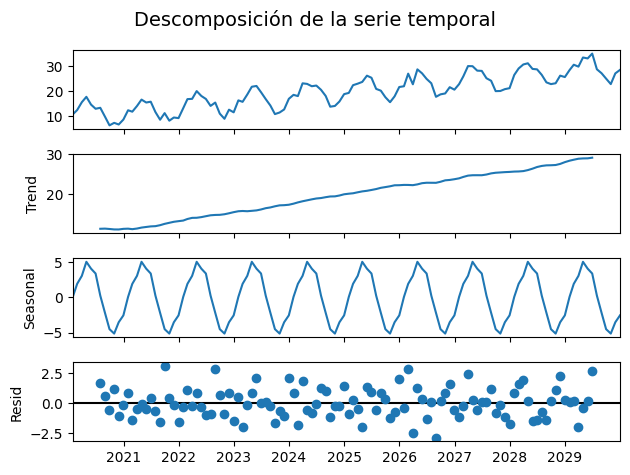

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Crear una serie temporal simulada
np.random.seed(42)
n = 120
fechas = pd.date_range(start="2020-01-01", periods=n, freq="M")

tendencia = np.linspace(10, 30, n)
estacionalidad = 5 * np.sin(2 * np.pi * np.arange(n) / 12)
ruido = np.random.normal(0, 1.5, n)

serie = pd.Series(tendencia + estacionalidad + ruido, index=fechas)

# Descomponer la serie temporal
descomposicion = seasonal_decompose(serie, model="additive", period=12)

# Visualizar los componentes
descomposicion.plot()
plt.suptitle("Descomposición de la serie temporal", fontsize=14)
plt.tight_layout()
plt.show()